In [1]:
import torch
import numpy as np
import random
import scanpy as sc
from sklearn.decomposition import PCA
import os
import pandas as pd
import sys

from utils import load_data
from model import Model, Trainer

/opt/miniconda3/envs/STC_ind/lib/python3.9/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
/opt/miniconda3/envs/STC_ind/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import sys
from opt_stMVC import get_args

original_argv = sys.argv
sys.argv = ['']  

try:
    args = get_args()
finally:
    sys.argv = original_argv  

print(args)

Namespace(cuda=True, device='cuda:1', seed=0, k_spatial=3, k_image=8, rad_cutoff=150, epoch_pre=200, epoch=1000, show_training_details=False, emb=True, refinement=False, num_clusters=10, name='CHD', slice='D10', lambda_1=10, lambda_2=50, lambda_3=10, lambda_4=5, vit_type='stMVC', r1=1.0, r2=0.0, lr=1e-05, lr_pr=0.01, start=0.01, end=4, adj_type='KNN')


In [3]:
torch.manual_seed(args.seed)
torch.cuda.manual_seed(args.seed)
torch.cuda.manual_seed_all(args.seed)
np.random.seed(args.seed)
random.seed(args.seed)
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

In [4]:
adata, A_P, A_I  = load_data(args)
X = torch.FloatTensor(adata.obsm["X_pca"])

/opt/miniconda3/envs/STC_ind/lib/python3.9/site-packages/scanpy/preprocessing/_deprecated/highly_variable_genes.py:131: UserWarning: If you pass `n_top_genes`, all cutoffs are ignored.
  warnings.warn(msg, UserWarning)


------Calculating spatial graph...
The graph contains 5748 edges, 1916 cells.
3.0000 neighbors per cell on average.


/data/guoyin/ST_HosImage/SUL/CL/st-Xprop_test/adj.py:40: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns['Spatial_Net'] = Spatial_Net


------Calculating spatial graph...
The graph contains 16135 edges, 1916 cells.
8.4212 neighbors per cell on average.


In [5]:

model = Model(A_P, A_I, args, n_nodes=X.shape[0], input_dim=X.shape[1]).to(args.device)
trainer = Trainer(model=model, device=args.device)
ari_df = trainer.fit(adata, adata.obs["ground_truth"], A_P, A_I, args)

preTraining…


100%|██████████| 201/201 [00:01<00:00, 184.77it/s]
/data/guoyin/ST_HosImage/SUL/CL/st-Xprop_test/training.py:69: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_sta

Training…


 99%|█████████▉| 993/1001 [00:10<00:00, 158.42it/s]

Running epochs:  1000
Evaluating n_clusters = 7


R callback write-console:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.1
Type 'citation("mclust")' for citing this R package in publications.
  


fitting ...
  |======================================================================| 100%


100%|█████████▉| 1000/1001 [00:14<00:00, 68.75it/s]


In [6]:
ari_df

,kmeans,mclust
0,0.632806,0.666295


In [7]:
adata

AnnData object with n_obs × n_vars = 1916 × 3000
    obs: 'ident', 'clusters', 'celltypes', 'region', 'ground_truth', 'kmeans', 'mclust'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'Spatial_Net'
    obsm: 'spatial', 'X_pca', 'image_spatial', 'st-Xprop'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced'

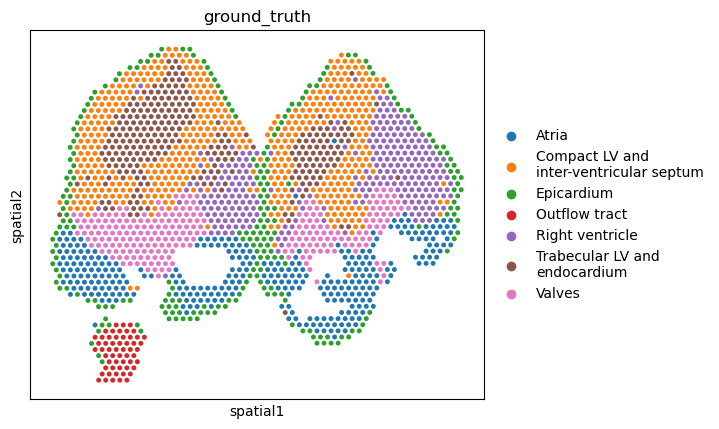

In [8]:
sc.pl.spatial(adata,  color=['ground_truth'],spot_size=150,size=1.3,color_map='viridis', show=True) 

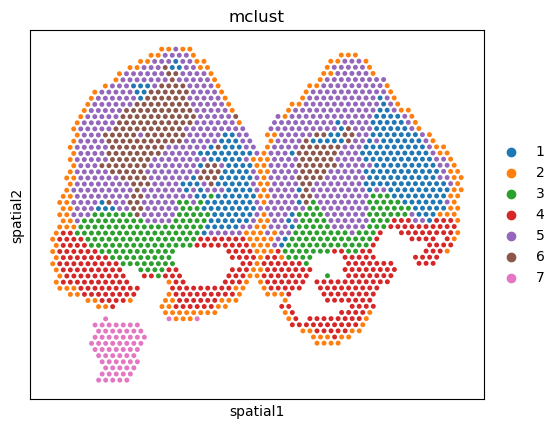

In [9]:
sc.pl.spatial(adata, color=[f'mclust'], spot_size=150, size=1.3, color_map='viridis')